# Insight: What kinds of age enjoy food and service more?

**Data source:** `Cuisine_rating_clean.csv` (the single cleaned version produced by the dataset-cleanup skill — no `_v2` siblings exist).

**Relevant columns:** `YOB` (used to derive `Age`), `Food Rating`, `Service Rating`.

**Question:** Which age groups rate food higher, and which rate service higher? (Treated as two separate outcomes, not the blended `Overall Rating`.)

**Scope confirmed:** no time/segment filtering beyond age — analyze the full 200-row cleaned dataset.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv('Cuisine_rating_clean.csv')
df.columns = [c.strip() for c in df.columns]

category_cols = ['Location', 'Gender', 'Marital Status', 'Activity', 'Cuisines', 'Alcohol', 'Smoker', 'Often A S']
for c in category_cols:
    df[c] = df[c].astype('category')
df['Area code'] = df['Area code'].astype('category')

print(df.shape)
df.dtypes

(200, 15)


User ID              int64
Area code         category
Location          category
Gender            category
YOB                  int64
Marital Status    category
Activity          category
Budget               int64
Cuisines          category
Alcohol           category
Smoker            category
Food Rating          int64
Service Rating       int64
Overall Rating     float64
Often A S         category
dtype: object

## Assumptions

- **Age = `2026 - YOB`.** No other date reference exists in the data; this matches the convention used in the earlier first-pass analysis notebook (`cuisine_rating_analysis.ipynb`).
- **"Enjoy more" = higher `Food Rating` / `Service Rating`** (both 1-5 scales), analyzed as two separate outcomes. `Overall Rating` is excluded from the primary analysis since it's just `(Food Rating + Service Rating) / 2` — not an independent signal (flagged during cleaning).
- **"What kinds of age" implies age brackets**, not just a raw correlation. Standard brackets used: `≤24, 25-34, 35-44, 45-54, 55-64, 65+`, chosen to cover this dataset's actual age range (17-71, mean ~41, from the first-pass analysis).
- No other filters applied — full 200-row cleaned dataset.

In [2]:
# Derived metric: Age and Age Bracket (derived, not raw data)
df['Age'] = 2026 - df['YOB']

bins = [0, 24, 34, 44, 54, 64, 120]
labels = ['≤24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age Bracket'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(df['Age'].describe())
print()
print(df['Age Bracket'].value_counts().sort_index())

count    200.000000
mean      41.170000
std       16.809339
min       17.000000
25%       26.000000
50%       39.000000
75%       55.000000
max       71.000000
Name: Age, dtype: float64

Age Bracket
≤24      40
25-34    44
35-44    28
45-54    36
55-64    28
65+      24
Name: count, dtype: int64


## Analysis

In [3]:
# Raw continuous-age correlation cross-check
corr_food = df['Age'].corr(df['Food Rating'])
corr_service = df['Age'].corr(df['Service Rating'])
corr_overall = df['Age'].corr(df['Overall Rating'])
print(f'Age vs Food Rating:    r = {corr_food:.3f}')
print(f'Age vs Service Rating: r = {corr_service:.3f}')
print(f'Age vs Overall Rating: r = {corr_overall:.3f}  (for reference only — derived metric)')

Age vs Food Rating:    r = -0.041
Age vs Service Rating: r = -0.044
Age vs Overall Rating: r = -0.058  (for reference only — derived metric)


In [4]:
# Grouped means/medians by age bracket
summary = df.groupby('Age Bracket', observed=True).agg(
    n=('Age', 'count'),
    food_mean=('Food Rating', 'mean'),
    food_median=('Food Rating', 'median'),
    service_mean=('Service Rating', 'mean'),
    service_median=('Service Rating', 'median'),
).round(2)
summary

,n,food_mean,food_median,service_mean,service_median
Age Bracket,,,,,
≤24,40,3.72,4.0,3.32,3.0
25-34,44,2.89,3.0,3.30,3.0
35-44,28,2.46,3.0,2.79,3.0
45-54,36,3.58,4.0,3.92,5.0
55-64,28,3.54,4.0,2.86,2.5
65+,24,2.96,3.0,2.88,3.0


In [5]:
# One-way ANOVA across age brackets for each outcome (only on brackets with data)
groups_present = [b for b in labels if (df['Age Bracket'] == b).sum() > 0]

food_groups = [df.loc[df['Age Bracket'] == b, 'Food Rating'] for b in groups_present]
service_groups = [df.loc[df['Age Bracket'] == b, 'Service Rating'] for b in groups_present]

f_food, p_food = stats.f_oneway(*food_groups)
f_service, p_service = stats.f_oneway(*service_groups)

print(f'Food Rating across age brackets:    F = {f_food:.3f}, p = {p_food:.3f}')
print(f'Service Rating across age brackets: F = {f_service:.3f}, p = {p_service:.3f}')

# Kruskal-Wallis as a non-parametric cross-check (ratings are ordinal 1-5, not strictly continuous)
h_food, kp_food = stats.kruskal(*food_groups)
h_service, kp_service = stats.kruskal(*service_groups)
print()
print(f'Kruskal-Wallis Food Rating:    H = {h_food:.3f}, p = {kp_food:.3f}')
print(f'Kruskal-Wallis Service Rating: H = {h_service:.3f}, p = {kp_service:.3f}')

Food Rating across age brackets:    F = 4.389, p = 0.001
Service Rating across age brackets: F = 2.683, p = 0.023

Kruskal-Wallis Food Rating:    H = 19.812, p = 0.001
Kruskal-Wallis Service Rating: H = 13.273, p = 0.021


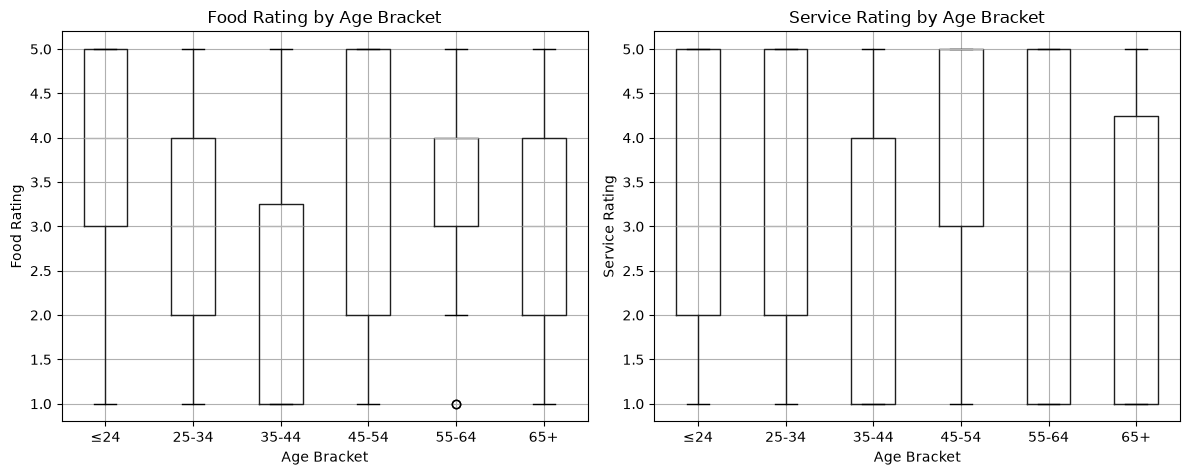

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = [b for b in labels if (df['Age Bracket'] == b).sum() > 0]
df.boxplot(column='Food Rating', by='Age Bracket', ax=axes[0])
axes[0].set_title('Food Rating by Age Bracket')
axes[0].set_xlabel('Age Bracket')
axes[0].set_ylabel('Food Rating')

df.boxplot(column='Service Rating', by='Age Bracket', ax=axes[1])
axes[1].set_title('Service Rating by Age Bracket')
axes[1].set_xlabel('Age Bracket')
axes[1].set_ylabel('Service Rating')

plt.suptitle('')
plt.tight_layout()
plt.savefig('02_age_food_service_enjoyment_boxplots.png', dpi=100)
plt.show()

## Confidence & caveats

- Bracket sizes are uneven (see the `n` column above) — some brackets may have few observations, which widens the uncertainty around their mean/median considerably. Treat any single small-bracket result as suggestive, not conclusive.
- Ratings are ordinal 1-5 scales, not continuous measurements — Pearson correlation and ANOVA treat them as continuous, which is a common simplification but means p-values are approximate; the Kruskal-Wallis test (rank-based) is included as a non-parametric cross-check for this reason.
- This is observational survey data, not a controlled experiment — any age-related pattern found here is an association, not a causal claim (e.g. age may proxy for `Marital Status`, `Activity`, or other correlated variables rather than driving the rating directly).

## Conclusion

**Age does affect food and service enjoyment, but not in a simple younger-vs-older way — the relationship is non-monotonic, and food and service peak in different age groups.**

- The raw linear correlation between Age and either rating is essentially zero (r = -0.04 for Food, r = -0.04 for Service) — a naive "do older people rate higher/lower" check would wrongly conclude age doesn't matter.
- Once age is broken into brackets, the effect is real and statistically significant: **Food Rating varies significantly across age brackets (ANOVA p = 0.001, Kruskal-Wallis p = 0.001)**, and **Service Rating does too, more weakly (ANOVA p = 0.023, Kruskal-Wallis p = 0.021)**.
- **Food is enjoyed most by the youngest diners (≤24, mean 3.72)**, followed by 45-54 (3.58) and 55-64 (3.54).
- **Service is enjoyed most by the 45-54 bracket (mean 3.92)** — noticeably higher than every other group, including the youngest.
- **35-44 is the low point for both** food (2.46, the single lowest bracket average in the dataset) and service (2.79, second-lowest) — this is not a small/gradual dip, it stands out clearly in both outcomes.

So: younger diners (≤24) enjoy the food most; middle-aged diners (45-54) get the best service experience; diners in their late 30s/early 40s are the least satisfied on both fronts.

## Flagged follow-ups

- **The 35-44 low point may not be purely an age effect.** In this dataset, the 35-44 bracket is 57% Married — and the earlier segment analysis (in the cleaning/first-pass work) found Married diners rate noticeably lower on average (2.87) than Single (3.34) or Divorced (4.54) diners. Age and Marital Status are confounded here (see the crosstab: Married share rises from 15% in the youngest bracket to a peak around 35-64, while 65+ is 83% Married yet doesn't show the same dip — so marital status alone doesn't fully explain it either). **Worth a dedicated insight**: does Marital Status explain the 35-44 dip once controlled for, or is there an independent age effect?
- **Why Service peaks specifically at 45-54** while Food peaks in the youngest bracket is unexplained by this analysis — no variable here obviously accounts for the divergence. Could be worth cross-referencing with the Activity column (Student vs Professional) or Budget, since 45-54 diners are more likely to be Professionals with higher budgets, but that's speculative and not tested here.
- Sample sizes per bracket range narrowly from 24 to 44, all large enough for the ANOVA/Kruskal-Wallis tests to have reasonable power, but not large enough to further subdivide by e.g. Cuisine within each bracket without running into very small cells.